In [1]:
# DAY 25 - CROSS-VALIDATION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the cleaned Sales dataset

df = pd.read_csv("../cleaned_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (51290, 23)


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,shipping_days,profit_margin
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,"Tenex Lockers, Blue",408.0,2,0.0,106.140,35.46,Medium,2011,5,26.014706
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Acme Trimmer, High Speed",120.0,3,0.1,36.036,9.72,Medium,2011,7,30.030000
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,"Tenex Box, Single Width",66.0,4,0.0,29.640,8.17,High,2011,4,44.909091
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,"Enermax Note Cards, Premium",45.0,3,0.5,-26.055,4.82,High,2011,4,-57.900000
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Eldon Light Bulb, Duo Pack",114.0,5,0.1,37.770,4.70,Medium,2011,7,33.131579


In [3]:
# Prepare features and target

feature_columns = [
    "sales",
    "quantity",
    "discount",
    "shipping_cost",
    "shipping_days"
]

X = df[feature_columns].astype(float)

# Target: 1 = positive profit, 0 = zero/negative profit
y = (df["profit"] > 0).astype(int)

print("Features prepared successfully!")
print("\nFeatures:")
print(feature_columns)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features prepared successfully!

Features:
['sales', 'quantity', 'discount', 'shipping_cost', 'shipping_days']

X shape: (51290, 5)
y shape: (51290,)


In [4]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-test split completed!")
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Train-test split completed!
Training data: (41032, 5)
Testing data: (10258, 5)


In [5]:
# Train Logistic Regression baseline model

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

print("Logistic Regression Accuracy:", round(logistic_accuracy, 3))

Logistic Regression Accuracy: 0.92


In [6]:
# Create K-Fold Cross-Validation

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold Cross-Validation created successfully!")

5-Fold Cross-Validation created successfully!


In [7]:
# Evaluate Logistic Regression using 5-Fold Cross-Validation

logistic_cv_scores = cross_val_score(
    logistic_model,
    X,
    y,
    cv=kfold,
    scoring="accuracy"
)

print("Logistic Regression CV Scores:")
print(logistic_cv_scores)

print("\nMean CV Accuracy:",
      round(logistic_cv_scores.mean(), 3))

print("Standard Deviation:",
      round(logistic_cv_scores.std(), 3))

Logistic Regression CV Scores:
[0.91606551 0.92162215 0.91840515 0.92025736 0.92249951]

Mean CV Accuracy: 0.92
Standard Deviation: 0.002


In [8]:
# Evaluate Decision Tree using 5-Fold Cross-Validation

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_cv_scores = cross_val_score(
    decision_tree_model,
    X,
    y,
    cv=kfold,
    scoring="accuracy"
)

print("Decision Tree CV Scores:")
print(decision_tree_cv_scores)

print("\nMean CV Accuracy:",
      round(decision_tree_cv_scores.mean(), 3))

print("Standard Deviation:",
      round(decision_tree_cv_scores.std(), 3))

Decision Tree CV Scores:
[0.87404952 0.87902125 0.87326964 0.8767791  0.88145837]

Mean CV Accuracy: 0.877
Standard Deviation: 0.003


In [9]:
# Evaluate Random Forest using 5-Fold Cross-Validation

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_cv_scores = cross_val_score(
    random_forest_model,
    X,
    y,
    cv=kfold,
    scoring="accuracy"
)

print("Random Forest CV Scores:")
print(random_forest_cv_scores)

print("\nMean CV Accuracy:",
      round(random_forest_cv_scores.mean(), 3))

print("Standard Deviation:",
      round(random_forest_cv_scores.std(), 3))

Random Forest CV Scores:
[0.91041139 0.91684539 0.91128875 0.91528563 0.91479821]

Mean CV Accuracy: 0.914
Standard Deviation: 0.002


In [10]:
# Compare cross-validation performance of all models

cv_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Mean CV Accuracy": [
        logistic_cv_scores.mean(),
        decision_tree_cv_scores.mean(),
        random_forest_cv_scores.mean()
    ],
    "Standard Deviation": [
        logistic_cv_scores.std(),
        decision_tree_cv_scores.std(),
        random_forest_cv_scores.std()
    ]
})

cv_comparison["Mean CV Accuracy"] = cv_comparison["Mean CV Accuracy"].round(3)
cv_comparison["Standard Deviation"] = cv_comparison["Standard Deviation"].round(3)

print(cv_comparison)

                 Model  Mean CV Accuracy  Standard Deviation
0  Logistic Regression             0.920               0.002
1        Decision Tree             0.877               0.003
2        Random Forest             0.914               0.002


In [11]:
# Compare train-test split with cross-validation

train_test_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Train-Test Accuracy": [
        logistic_accuracy,
        np.nan,
        np.nan
    ],
    "Mean CV Accuracy": [
        logistic_cv_scores.mean(),
        decision_tree_cv_scores.mean(),
        random_forest_cv_scores.mean()
    ],
    "CV Standard Deviation": [
        logistic_cv_scores.std(),
        decision_tree_cv_scores.std(),
        random_forest_cv_scores.std()
    ]
})

train_test_comparison = train_test_comparison.round(3)

print(train_test_comparison)

                 Model  Train-Test Accuracy  Mean CV Accuracy  \
0  Logistic Regression                 0.92             0.920   
1        Decision Tree                  NaN             0.877   
2        Random Forest                  NaN             0.914   

   CV Standard Deviation  
0                  0.002  
1                  0.003  
2                  0.002  


In [12]:
# Train Decision Tree and Random Forest using train-test split

decision_tree_model.fit(
    X_train,
    y_train
)

random_forest_model.fit(
    X_train,
    y_train
)

decision_tree_pred = decision_tree_model.predict(X_test)
random_forest_pred = random_forest_model.predict(X_test)

decision_tree_accuracy = accuracy_score(
    y_test,
    decision_tree_pred
)

random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_pred
)

print("Decision Tree Accuracy:",
      round(decision_tree_accuracy, 3))

print("Random Forest Accuracy:",
      round(random_forest_accuracy, 3))

Decision Tree Accuracy: 0.871
Random Forest Accuracy: 0.913


In [13]:
# Final comparison: Train-Test vs Cross-Validation

final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Train-Test Accuracy": [
        logistic_accuracy,
        decision_tree_accuracy,
        random_forest_accuracy
    ],
    "Mean CV Accuracy": [
        logistic_cv_scores.mean(),
        decision_tree_cv_scores.mean(),
        random_forest_cv_scores.mean()
    ],
    "CV Standard Deviation": [
        logistic_cv_scores.std(),
        decision_tree_cv_scores.std(),
        random_forest_cv_scores.std()
    ]
})

final_comparison = final_comparison.round(3)

print(final_comparison)

                 Model  Train-Test Accuracy  Mean CV Accuracy  \
0  Logistic Regression                0.920             0.920   
1        Decision Tree                0.871             0.877   
2        Random Forest                0.913             0.914   

   CV Standard Deviation  
0                  0.002  
1                  0.003  
2                  0.002  


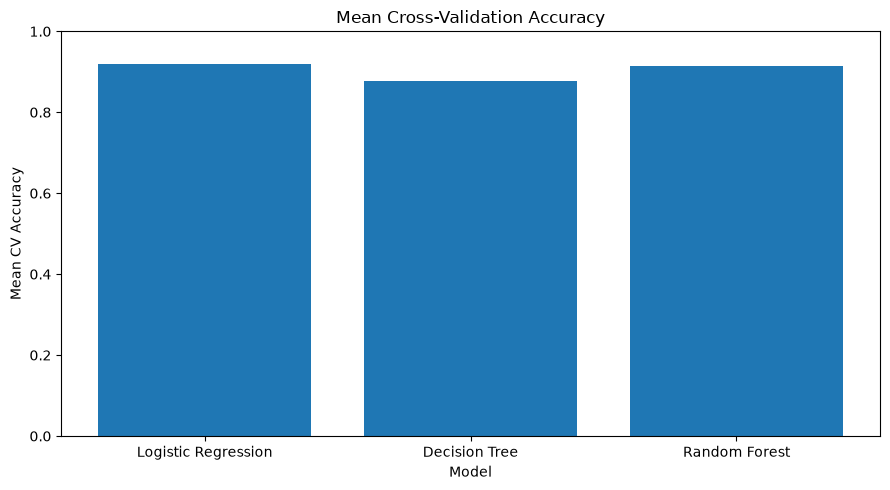

In [14]:
# Visualize model performance using Cross-Validation

plt.figure(figsize=(9, 5))

plt.bar(
    final_comparison["Model"],
    final_comparison["Mean CV Accuracy"]
)

plt.title("Mean Cross-Validation Accuracy")
plt.xlabel("Model")
plt.ylabel("Mean CV Accuracy")
plt.ylim(0, 1)

plt.tight_layout()

plt.show()

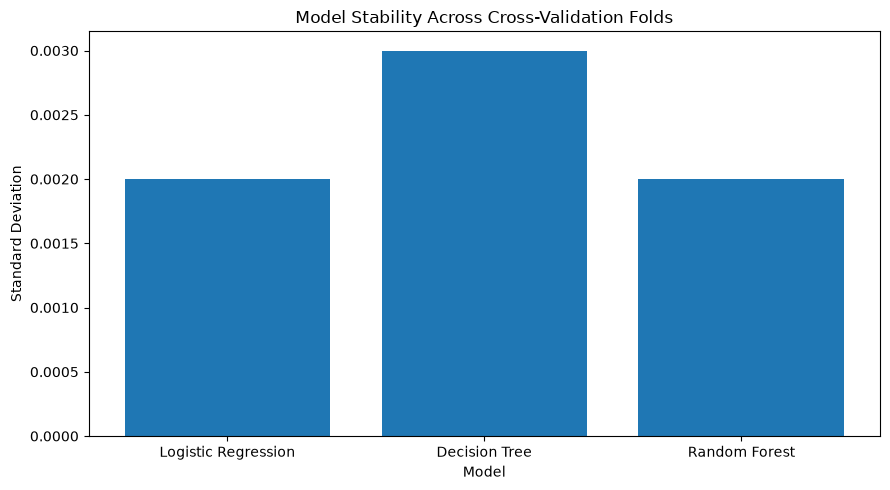

In [15]:
# Visualize model stability using CV standard deviation

plt.figure(figsize=(9, 5))

plt.bar(
    final_comparison["Model"],
    final_comparison["CV Standard Deviation"]
)

plt.title("Model Stability Across Cross-Validation Folds")
plt.xlabel("Model")
plt.ylabel("Standard Deviation")

plt.tight_layout()

plt.show()

In [16]:
# Save the final performance comparison

final_comparison.to_csv(
    "cross_validation_comparison.csv",
    index=False
)

print("Performance comparison saved successfully!")
print("File: cross_validation_comparison.csv")

Performance comparison saved successfully!
File: cross_validation_comparison.csv


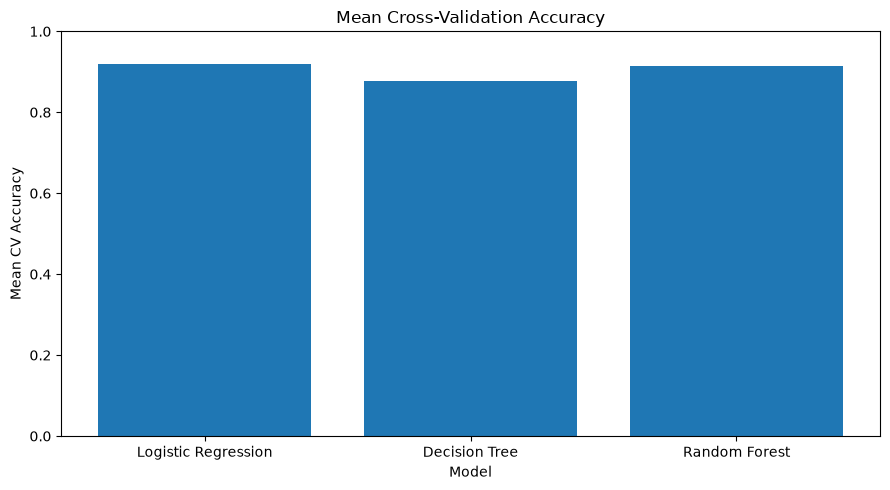

Cross-Validation accuracy graph saved successfully!


In [17]:
# Save the Cross-Validation accuracy graph

plt.figure(figsize=(9, 5))

plt.bar(
    final_comparison["Model"],
    final_comparison["Mean CV Accuracy"]
)

plt.title("Mean Cross-Validation Accuracy")
plt.xlabel("Model")
plt.ylabel("Mean CV Accuracy")
plt.ylim(0, 1)

plt.tight_layout()

plt.savefig(
    "cross_validation_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Cross-Validation accuracy graph saved successfully!")

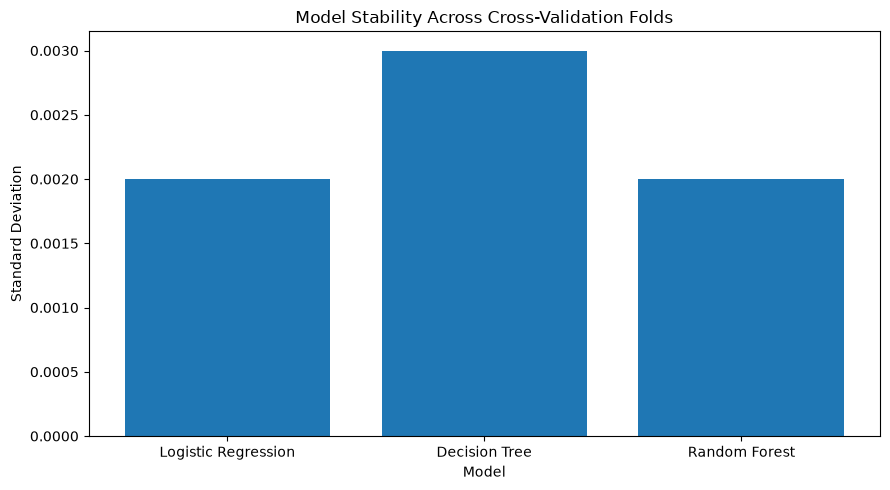

Model stability graph saved successfully!


In [18]:
# Save the model stability graph

plt.figure(figsize=(9, 5))

plt.bar(
    final_comparison["Model"],
    final_comparison["CV Standard Deviation"]
)

plt.title("Model Stability Across Cross-Validation Folds")
plt.xlabel("Model")
plt.ylabel("Standard Deviation")

plt.tight_layout()

plt.savefig(
    "model_stability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Model stability graph saved successfully!")

In [19]:
# Final Day 25 file check

import os

files = [
    "cross_validation_comparison.csv",
    "cross_validation_accuracy.png",
    "model_stability.png"
]

print("Day 25 files:")

for file in files:
    if os.path.exists(file):
        print("✅", file)
    else:
        print("❌", file)

Day 25 files:
✅ cross_validation_comparison.csv
✅ cross_validation_accuracy.png
✅ model_stability.png
